# 1D-CNN 기반 네트워크 침입 탐지 (v5 - SMOTE + SSAE + DeepCNN)

- **SMOTE 오버샘플링**: 불균형이 심한 원본 학습 데이터(`X_train`)에 SMOTE를 적용하여 모든 클래스의 샘플 수를 다수 클래스 수준으로 맞춤
- **SSAE 사전 학습**: 오버샘플링된 균형 데이터로 L1 제약(1e-3) 비지도 학습을 진행하여 중요 피처(64개) 추출
- **Step 3. DeepCNN 지도 학습**: 4-Block CNN+1D망으로 분류.

## 1. 라이브러리 임포트

In [1]:
!pip install imbalanced-learn
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch version : 2.11.0+cu126
Device          : cuda


## 2. 데이터 로드 및 분할

In [2]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

# Train 70 / Val 15 / Test 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print("원본 Train 데이터 분포:", Counter(y_train))

원본 Train 데이터 분포: Counter({np.int32(0): 350000, np.int32(4): 350000, np.int32(3): 350000, np.int32(2): 267253, np.int32(1): 200333, np.int32(5): 113354, np.int32(6): 700})


## 3. SMOTE 적용 (학습 데이터 오버샘플링)

In [4]:
print("SMOTE 오버샘플링 진행 중...")
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("SMOTE 적용 후 Train 데이터 분포:", Counter(y_train_res))

SMOTE 오버샘플링 진행 중...
SMOTE 적용 후 Train 데이터 분포: Counter({np.int32(0): 350000, np.int32(4): 350000, np.int32(2): 350000, np.int32(3): 350000, np.int32(1): 350000, np.int32(5): 350000, np.int32(6): 350000})


## 4. Dataset & DataLoader

In [5]:
class IDSDataset_Vector(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 512

train_loader = DataLoader(IDSDataset_Vector(X_train_res, y_train_res), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(IDSDataset_Vector(X_val,       y_val),       batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(IDSDataset_Vector(X_test,      y_test),      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 5. SSAE (Stacked Sparse Autoencoder) 모델 학습

In [6]:
class SSAE(nn.Module):
    def __init__(self, input_dim=70, hidden_dim=64):
        super().__init__()
        self.enc1 = nn.Linear(input_dim, 128)
        self.enc2 = nn.Linear(128, hidden_dim)
        
        self.dec1 = nn.Linear(hidden_dim, 128)
        self.dec2 = nn.Linear(128, input_dim)
        
    def encode(self, x):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(e1))
        return e2, e1 # L1 페널티용
        
    def forward(self, x):
        e2, e1 = self.encode(x)
        d1 = torch.relu(self.dec1(e2))
        out = torch.sigmoid(self.dec2(d1)) 
        return out, e2, e1

ssae = SSAE(input_dim=X_train.shape[1], hidden_dim=64).to(DEVICE)
ssae_criterion = nn.MSELoss()
ssae_optimizer = optim.Adam(ssae.parameters(), lr=1e-3)

L1_LAMBDA = 1e-3
SSAE_EPOCHS = 10

print("=== 비지도 학습: SSAE (특징 중요도 추출 및 노이즈 제거) ===")
ssae.train()
for epoch in range(1, SSAE_EPOCHS + 1):
    total_loss = 0.0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(DEVICE)
        out, e2, e1 = ssae(X_batch)
        
        mse_loss = ssae_criterion(out, X_batch)
        l1_loss  = e1.abs().mean() + e2.abs().mean()
        loss = mse_loss + L1_LAMBDA * l1_loss
        
        ssae_optimizer.zero_grad()
        loss.backward()
        ssae_optimizer.step()
        
        total_loss += loss.item() * len(X_batch)
        
    print(f"SSAE Epoch {epoch:02d}/{SSAE_EPOCHS} | Loss: {total_loss/len(train_loader.dataset):.6f}")

torch.save(ssae.state_dict(), os.path.join(MODEL_DIR, "ssae_pretrained_v5.pt"))
print("SSAE 학습 및 가중치 저장 완료.\n")

=== 비지도 학습: SSAE (특징 중요도 추출 및 노이즈 제거) ===
SSAE Epoch 01/10 | Loss: 0.716469
SSAE Epoch 02/10 | Loss: 0.709896
SSAE Epoch 03/10 | Loss: 0.709662
SSAE Epoch 04/10 | Loss: 0.709560
SSAE Epoch 05/10 | Loss: 0.709482
SSAE Epoch 06/10 | Loss: 0.709447
SSAE Epoch 07/10 | Loss: 0.709409
SSAE Epoch 08/10 | Loss: 0.709385
SSAE Epoch 09/10 | Loss: 0.709383
SSAE Epoch 10/10 | Loss: 0.709369
SSAE 학습 및 가중치 저장 완료.



## 6. 특징 추출 및 DeepCNN 설계

In [7]:
class SSAE_DeepCNN(nn.Module):
    def __init__(self, encoder, num_classes=7):
        super().__init__()
        self.encoder = encoder
        
        def make_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.BatchNorm1d(out_ch),
                nn.Dropout(0.3)
            )
            
        self.cnn = nn.Sequential(
            make_block(1, 32),   # 64 -> 32 len
            make_block(32, 64),  # 32 -> 16 len
            make_block(64, 128), # 16 ->  8 len
            make_block(128, 256) # 8  ->  4 len
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        e2, _ = self.encoder.encode(x) # (B, 64)
        out = e2.unsqueeze(1)          # (B, 1, 64)
        out = self.cnn(out)
        out = self.classifier(out)
        return out

model = SSAE_DeepCNN(encoder=ssae, num_classes=num_classes).to(DEVICE)
print(f"총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

총 파라미터 수: 1,018,221


## 7. DeepCNN 학습 (분류기)

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

EPOCHS = 50
PATIENCE = 7
BEST_PATH = os.path.join(MODEL_DIR, "best_model_v5.pt")

best_val_loss = float("inf")
patience_cnt = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total

print("\n=== 지도 학습: SMOTE 된 데이터로 DeepCNN 분류 ===")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    
    scheduler.step(vl_loss)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = " ★" if vl_loss < best_val_loss else ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        patience_cnt += 1
        
    print(f"Epoch {epoch:02d}/{EPOCHS}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}{marker}")
    
    if patience_cnt >= PATIENCE:
        print(f"\nEarly Stopping (patience={PATIENCE})")
        break



=== 지도 학습: SMOTE 된 데이터로 DeepCNN 분류 ===
Epoch 01/50  train_loss=0.2338 train_acc=0.8701 val_loss=0.2288 val_acc=0.8760 ★
Epoch 02/50  train_loss=0.2179 train_acc=0.8765 val_loss=0.2414 val_acc=0.8598
Epoch 03/50  train_loss=0.2145 train_acc=0.8776 val_loss=0.2258 val_acc=0.8395 ★
Epoch 04/50  train_loss=0.2113 train_acc=0.8792 val_loss=0.2221 val_acc=0.8506 ★
Epoch 05/50  train_loss=0.2095 train_acc=0.8808 val_loss=0.2237 val_acc=0.8540
Epoch 06/50  train_loss=0.2081 train_acc=0.8816 val_loss=0.2271 val_acc=0.8418
Epoch 07/50  train_loss=0.2060 train_acc=0.8827 val_loss=0.2292 val_acc=0.8424
Epoch 08/50  train_loss=0.2052 train_acc=0.8836 val_loss=0.2245 val_acc=0.8481
Epoch 09/50  train_loss=0.2047 train_acc=0.8841 val_loss=0.2147 val_acc=0.8995 ★
Epoch 10/50  train_loss=0.2038 train_acc=0.8844 val_loss=0.2176 val_acc=0.8488
Epoch 11/50  train_loss=0.2036 train_acc=0.8845 val_loss=0.2227 val_acc=0.8662
Epoch 12/50  train_loss=0.2032 train_acc=0.8845 val_loss=0.2208 val_acc=0.8482
Epoc

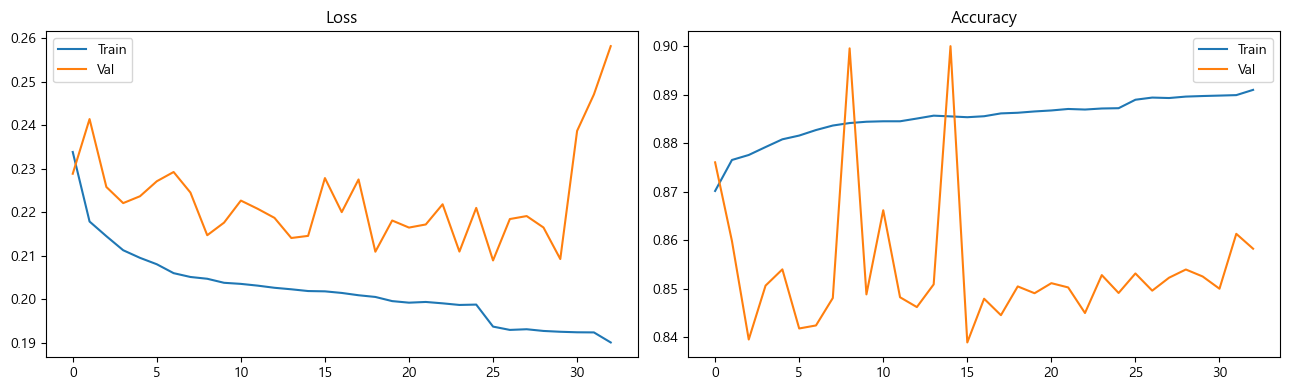

In [9]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")

for ax in axes: ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

## 8. 모델 성능 평가

In [10]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("=== Classification Report (v5: SMOTE + SSAE + DeepCNN) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

=== Classification Report (v5: SMOTE + SSAE + DeepCNN) ===
               precision    recall  f1-score   support

       Benign     0.9180    0.5133    0.6584     75000
          Bot     0.9999    0.9999    0.9999     42929
  Brute Force     0.8606    0.9577    0.9065     57269
         DDoS     0.9999    0.9999    0.9999     75000
          DoS     0.9656    0.8816    0.9217     75000
 Infiltration     0.3641    0.8595    0.5115     24290
SQL Injection     0.6148    1.0000    0.7614       150

     accuracy                         0.8535    349638
    macro avg     0.8176    0.8874    0.8228    349638
 weighted avg     0.9078    0.8535    0.8606    349638



## 9. 모델 저장

In [ ]:
meta = {
    "version"        : "v5",
    "loss"           : "CrossEntropyLoss (Oversampled) / L1 제약",
    "architecture"   : "SMOTE + SSAE (Encoder) + DeepCNN (4-Block 1D-CNN)",
    "num_features"   : X_train.shape[1],
    "num_classes"    : num_classes,
    "class_names"    : class_names,
    "best_val_loss"  : round(best_val_loss, 6),
}
with open(os.path.join(MODEL_DIR, "model_meta_v5.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("v5 메타데이터 저장 완료!")